#  פרויקט: זיהוי חדשות כוזבות ברשת (Fake News Detection)

## שלב 1: ניתוח נתונים (EDA) ועיבוד מקדים (Preprocessing)

---
#משתתפים
#אחמד אלדדה 326087244
# אבראהים אבו קוש 326501905
# 214042517 עבד אלרחמן אלנבארי


### מטרת המחברת בשלב זה:

1. **להבין את מבנה הנתונים** ואת ההתפלגויות המרכזיות (EDA).
2. **לבצע ניקוי ועיבוד מקדים בסיסי** לטקסט.
3. **בשלב זה לא נבנה מודל למידת מכונה** — שלב זה מהווה בסיס חשוב לבנייתו בהמשך.

---

### רעיון הפרויקט:

בעידן הרשתות החברתיות, חדשות כוזבות (Fake News) מתפשטות במהירות רבה ועלולות לגרום נזק ממשי לציבור.
מטרת פרויקט זה היא לבנות מודל שמסוגל לזהות אוטומטית האם כתבת חדשות היא **אמיתית** או **כוזבת**,
על בסיס ניתוח תוכן הטקסט בלבד.

זהו יישום מעשי חשוב בתחום עיבוד שפה טבעית (NLP) ולמידת מכונה, עם השפעה ישירה על חברה ודמוקרטיה.

## (1) מקור הנתונים ותיאור כללי

הנתונים נלקחו מ-**Kaggle** — פלטפורמה מוכרת לתחרויות מדעי נתונים:

> https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

### הקבצים שנשתמש בהם:
- `Fake.csv` — כתבות חדשות **כוזבות** (label = 1)
- `True.csv` — כתבות חדשות **אמיתיות** (label = 0)

### עמודות הנתונים:
| עמודה | תיאור |
|-------|--------|
| `title` | כותרת הכתבה |
| `text` | תוכן הכתבה המלא |
| `subject` | קטגוריית הנושא |
| `date` | תאריך הפרסום |
| `label` | 1 = כוזב, 0 = אמיתי |

אנו נאחד את עמודות `title` ו-`text` לעמודה אחת בשם `content` לצורך הניתוח.

In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = ""
os.environ["KAGGLE_KEY"] = ""

## הגדרת מפתח Kaggle והורדת הנתונים

נגדיר את פרטי ה-API של Kaggle כדי לאפשר הורדה אוטומטית של הנתונים ישירות לסביבת Colab.

In [ ]:
# התקנת ספריית Kaggle והורדת הדאטה
!pip install -q kaggle
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset
!unzip -o fake-and-real-news-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
100% 41.0M/41.0M [00:00<00:00, 150MB/s]

Archive:  fake-and-real-news-dataset.zip
  inflating: Fake.csv                
  inflating: True.csv                


## ייבוא ספריות

נייבא את כל הספריות הנדרשות לניתוח הנתונים והויזואליזציה:
- `pandas` — לעבודה עם טבלאות נתונים
- `matplotlib` ו-`seaborn` — לגרפים וויזואליזציות
- `re` — לביטויים רגולריים לניקוי טקסט
- `Counter` — לספירת מילים נפוצות

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

print("✅ כל הספריות נטענו בהצלחה")

✅ כל הספריות נטענו בהצלחה


## (2) טעינת הנתונים

נטען את שני קבצי ה-CSV — הכוזב והאמיתי — ונוסיף לכל אחד תווית (label):
- **Fake.csv** → label = 1 (כוזב)
- **True.csv** → label = 0 (אמיתי)

לאחר מכן נאחד אותם לטבלה אחת ונבדוק את הצורה הכללית של הדאטה.

In [ ]:
# טעינת קבצי הנתונים
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

# הוספת תוויות
fake_df["label"] = 1   # כוזב
true_df["label"] = 0   # אמיתי

# איחוד הטבלאות
df = pd.concat([fake_df, true_df], ignore_index=True)

print(f"📁 גודל קובץ Fake: {fake_df.shape}")
print(f"📁 גודל קובץ True: {true_df.shape}")
print(f"📦 גודל הדאטה המאוחד: {df.shape}")

📁 גודל קובץ Fake: (23481, 5)
📁 גודל קובץ True: (21417, 5)
📦 גודל הדאטה המאוחד: (44898, 5)


### יצירת עמודת תוכן מאוחדת

נאחד את עמודות `title` (כותרת) ו-`text` (גוף הכתבה) לעמודה אחת בשם `content`.
זה מאפשר לנו לנתח את הטקסט המלא של כל כתבה כיחידה אחת.

In [ ]:
# יצירת עמודת תוכן מאוחדת מכותרת + גוף הכתבה
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")
df = df[["content", "label"]].dropna()

print(f"✅ גודל הדאטה לאחר עיבוד: {df.shape}")
print(f"   - מספר שורות: {df.shape[0]:,}")
print(f"   - מספר עמודות: {df.shape[1]}")
df.head()

✅ גודל הדאטה לאחר עיבוד: (44898, 2)
   - מספר שורות: 44,898
   - מספר עמודות: 2


,content,label
0,"Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",1
1,"Drunk Bragging Trump Staffer Started Russian Collusion Investigation House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us,...",1
2,"Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’ On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homel...",1
3,"Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES) On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for the...",1
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope delivere...,1


## (3) הצגת הדאטה — מבנה ותיאור סטטיסטי

נציג דוגמאות ראשונות, מבנה הנתונים, ותיאור סטטיסטי בסיסי כדי להבין את הנתונים לפני הניתוח.

In [ ]:
# מבנה הנתונים
print("📊 מידע על הדאטה:")
df.info()

📊 מידע על הדאטה:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  44898 non-null  object
 1   label    44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


In [ ]:
# תיאור סטטיסטי
print("📈 תיאור סטטיסטי:")
df.describe(include="all").T

📈 תיאור סטטיסטי:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
content,44898,39105,Highlights: The Trump presidency on April 13 at 9:30 P.M. EDT/0130 GMT on Friday (Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a mass...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,44898.0,NaN,NaN,NaN,0.522985,0.499477,0.0,0.0,1.0,1.0,1.0


In [ ]:
# בדיקת ערכים חסרים
print("🔍 ערכים חסרים בכל עמודה:")
print(df.isnull().sum())

🔍 ערכים חסרים בכל עמודה:
content    0
label      0
dtype: int64


## (4) ניתוח סטטיסטי — EDA

בשלב זה נבצע ניתוח מעמיק של הנתונים:
- התפלגות המחלקות (אמיתי/כוזב)
- אורך הטקסטים (מספר תווים)
- מספר מילים לכתבה
- המילים הנפוצות ביותר

### 4.1 התפלגות המחלקות

נבדוק כמה כתבות כוזבות (label=1) וכמה כתבות אמיתיות (label=0) יש בדאטה.
חשוב לדעת אם הדאטה **מאוזן** (balanced) או לא, כי אי-איזון משפיע על בחירת המודל ומדדי ההערכה.

In [ ]:
# ספירת מחלקות
label_counts = df["label"].value_counts().sort_index()
print("📊 התפלגות מחלקות:")
print(f"  כתבות אמיתיות (0): {label_counts[0]:,}")
print(f"  כתבות כוזבות  (1): {label_counts[1]:,}")
print(f"  סה\"כ: {label_counts.sum():,}")
print(f"\n  אחוז כוזב: {label_counts[1]/label_counts.sum()*100:.1f}%")
print(f"  אחוז אמיתי: {label_counts[0]/label_counts.sum()*100:.1f}%")

📊 התפלגות מחלקות:
  כתבות אמיתיות (0): 21,417
  כתבות כוזבות  (1): 23,481
  סה"כ: 44,898

  אחוז כוזב: 52.3%
  אחוז אמיתי: 47.7%


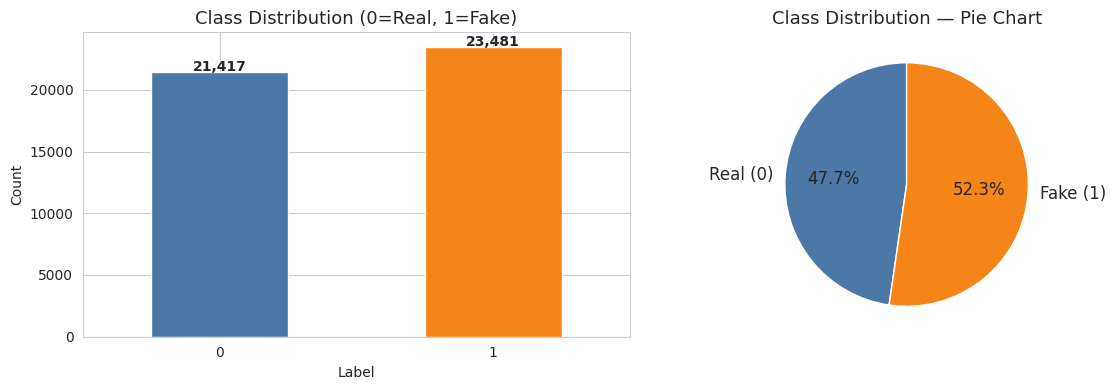

In [ ]:
# גרף התפלגות מחלקות
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# גרף עמודות
label_counts.plot(kind="bar", color=["#4C78A8", "#F58518"], ax=axes[0])
axes[0].set_title("Class Distribution (0=Real, 1=Fake)", fontsize=13)
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 100, f"{v:,}", ha='center', fontweight='bold')

# גרף עוגה
axes[1].pie(label_counts, labels=["Real (0)", "Fake (1)"],
            colors=["#4C78A8", "#F58518"], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Class Distribution — Pie Chart", fontsize=13)

plt.tight_layout()
plt.show()

### 4.2 אורך טקסטים (מספר תווים)

נחשב את אורך כל כתבה במספר תווים, ונבדוק:
- מהו האורך הממוצע?
- האם יש הבדל באורך בין כתבות כוזבות לאמיתיות?

In [ ]:
# חישוב אורך טקסט
df["text_length"] = df["content"].astype(str).apply(len)

print("📏 סטטיסטיקות אורך טקסט (מספר תווים):")
print(df["text_length"].describe().round(2))

📏 סטטיסטיקות אורך טקסט (מספר תווים):
count    44898.00
mean      2550.22
std       2172.58
min         31.00
25%       1318.00
50%       2270.00
75%       3189.00
max      51893.00
Name: text_length, dtype: float64


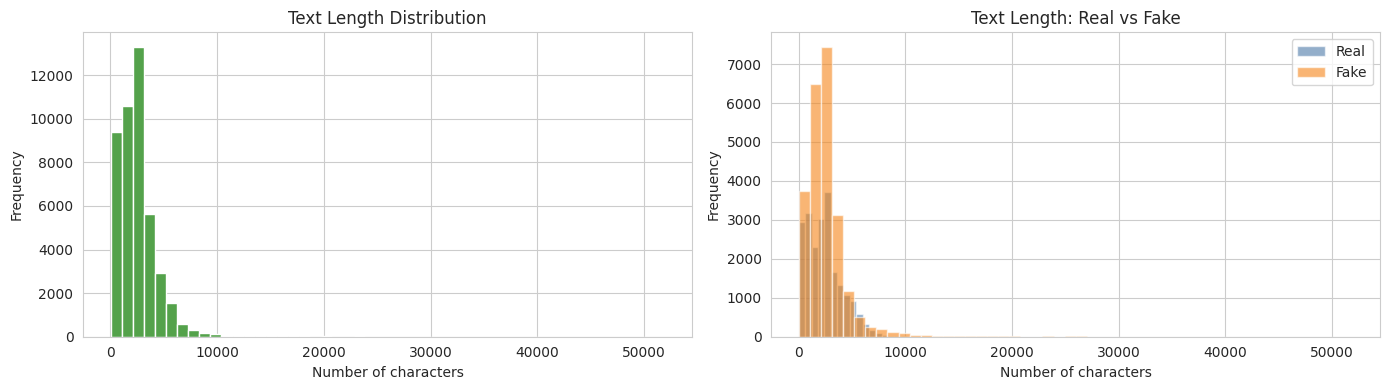

In [ ]:
# גרפים של אורך טקסט
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# היסטוגרמה כללית
df["text_length"].hist(bins=50, color="#54A24B", ax=axes[0])
axes[0].set_title("Text Length Distribution")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Frequency")

# השוואה בין מחלקות
df[df["label"]==0]["text_length"].hist(bins=50, alpha=0.6, color="#4C78A8", label="Real", ax=axes[1])
df[df["label"]==1]["text_length"].hist(bins=50, alpha=0.6, color="#F58518", label="Fake", ax=axes[1])
axes[1].set_title("Text Length: Real vs Fake")
axes[1].set_xlabel("Number of characters")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.3 מספר מילים לכתבה

נחשב את מספר המילים בכל כתבה (על ידי פיצול הטקסט לפי רווחים).
מדד זה מעניין יותר מאורך תווים כי הוא מייצג טוב יותר את "כמות המידע" בכתבה.

In [ ]:
# חישוב מספר מילים
df["word_count"] = df["content"].astype(str).apply(lambda x: len(x.split()))

print("📝 סטטיסטיקות מספר מילים לכתבה:")
print(df["word_count"].describe().round(2))

📝 סטטיסטיקות מספר מילים לכתבה:
count    44898.00
mean       417.74
std        351.48
min          2.00
25%        216.00
50%        375.00
75%        526.00
max       8148.00
Name: word_count, dtype: float64


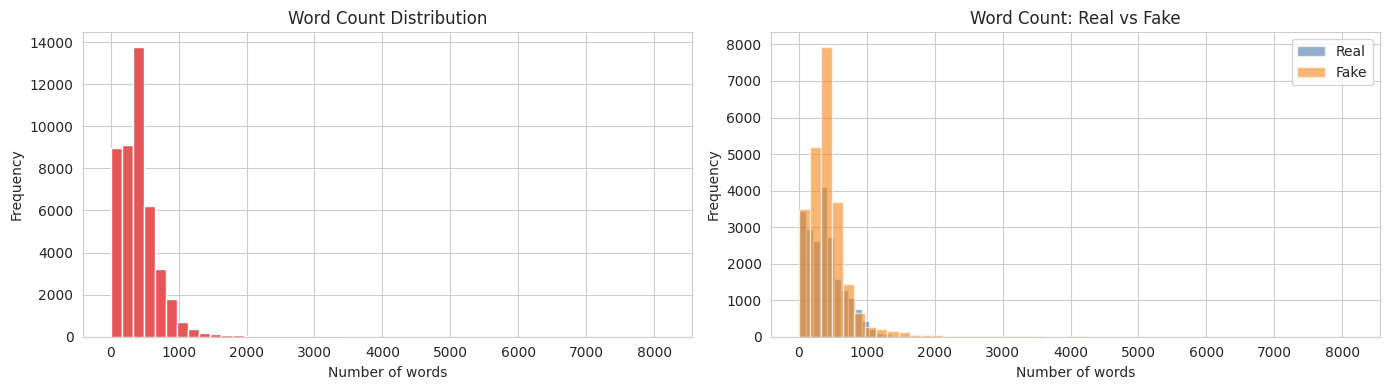

In [ ]:
# גרפים של מספר מילים
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# היסטוגרמה כללית
df["word_count"].hist(bins=50, color="#E45756", ax=axes[0])
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Frequency")

# השוואה בין מחלקות
df[df["label"]==0]["word_count"].hist(bins=50, alpha=0.6, color="#4C78A8", label="Real", ax=axes[1])
df[df["label"]==1]["word_count"].hist(bins=50, alpha=0.6, color="#F58518", label="Fake", ax=axes[1])
axes[1].set_title("Word Count: Real vs Fake")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.4 מילים נפוצות (Top Words)

נציג את **20 המילים הנפוצות ביותר** בכל הדאטה לאחר ניקוי בסיסי.

⚠️ **שים לב:** בשלב זה המילים הנפוצות ביותר הן מילות תפל (stop words) כמו "the", "and", "is".
בשלב העיבוד המקדים המתקדם נסיר אותן כדי למצוא מילים בעלות משמעות אמיתית.

In [ ]:
# ניתוח מילים נפוצות — כל הדאטה
all_words = " ".join(df["content"].astype(str).str.lower().tolist())
all_words = re.sub(r"http\S+", "", all_words)
all_words = re.sub(r"[^a-z\s]", " ", all_words)
tokens = [w for w in all_words.split() if len(w) > 2]

top_words = Counter(tokens).most_common(20)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

print("🔤 20 המילים הנפוצות ביותר:")
top_words_df

🔤 20 המילים הנפוצות ביותר:


,word,count
0,the,1033853
1,and,413713
2,that,241227
3,for,181043
4,trump,149523
5,said,133033
6,with,121921
7,was,116791
8,his,98232
9,has,89524


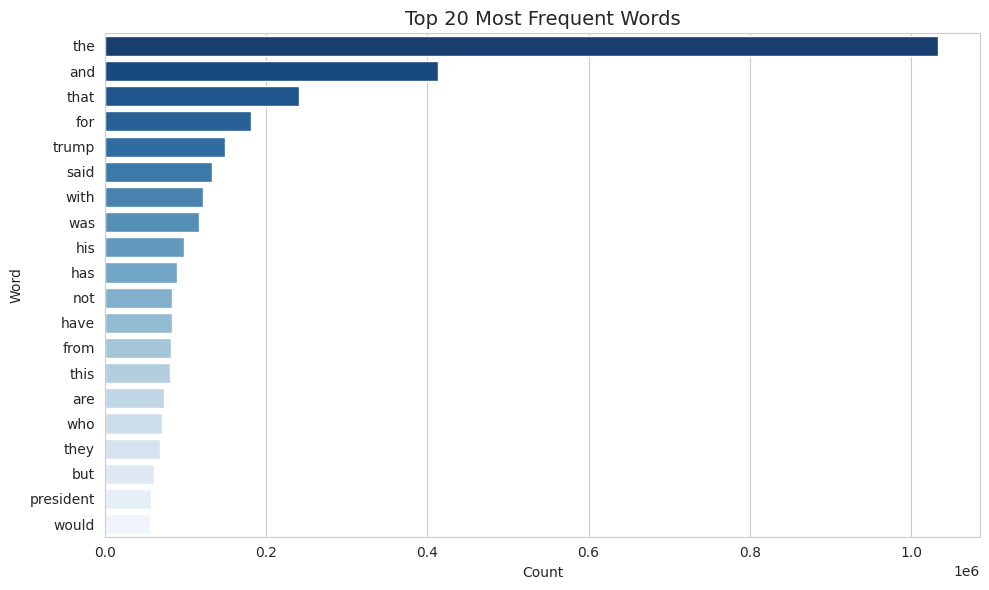

In [ ]:
# גרף מילים נפוצות
plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x="count", y="word",
            hue="word", palette="Blues_r", legend=False)
plt.title("Top 20 Most Frequent Words", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

### 4.5 מילים נפוצות — השוואה בין כוזב לאמיתי

ניתוח מעניין: אילו מילים **אופייניות לכתבות כוזבות** ואילו **אופייניות לכתבות אמיתיות**?
זה יכול לתת לנו רמזים ראשונים על מאפיינים שיעזרו למודל.

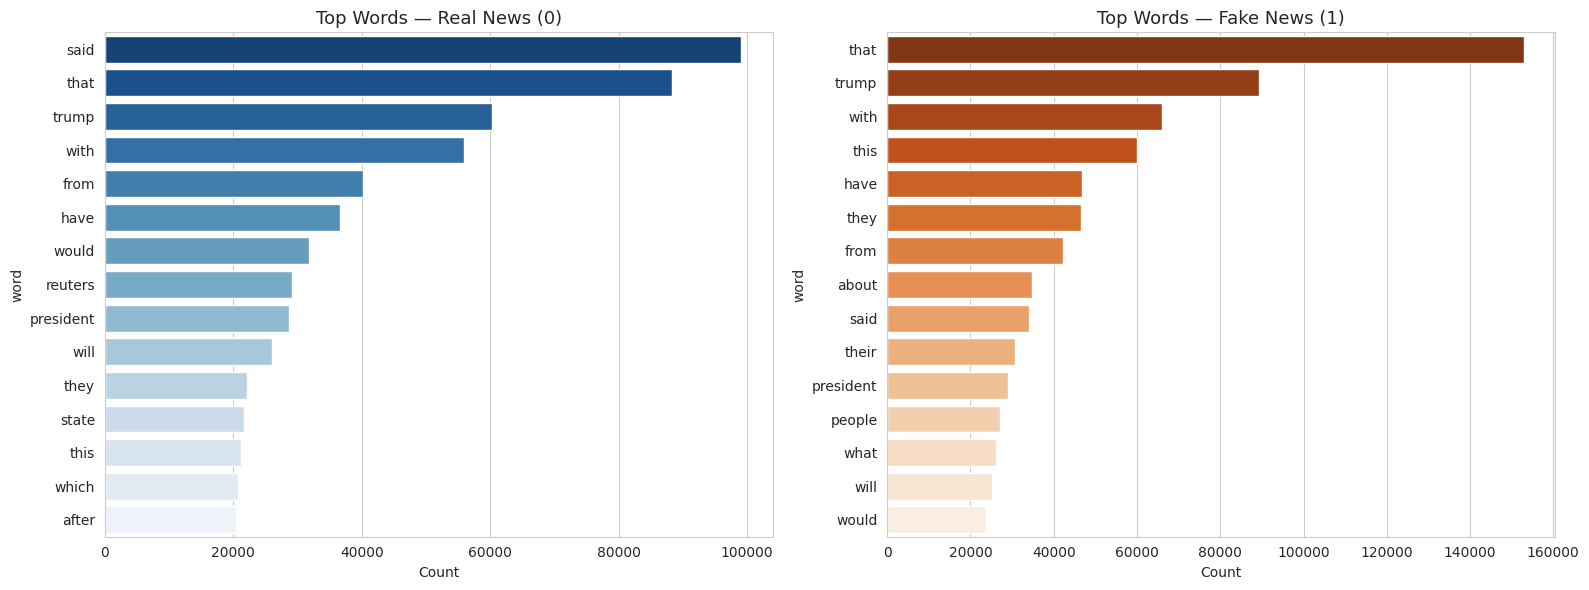

In [ ]:
def get_top_words(dataframe, label_val, n=15):
    texts = " ".join(dataframe[dataframe["label"]==label_val]["content"].astype(str).str.lower().tolist())
    texts = re.sub(r"http\S+", "", texts)
    texts = re.sub(r"[^a-z\s]", " ", texts)
    tokens = [w for w in texts.split() if len(w) > 3]
    return pd.DataFrame(Counter(tokens).most_common(n), columns=["word", "count"])

real_top = get_top_words(df, 0)
fake_top = get_top_words(df, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=real_top, x="count", y="word",
            hue="word", palette="Blues_r", legend=False, ax=axes[0])
axes[0].set_title("Top Words — Real News (0)", fontsize=13)
axes[0].set_xlabel("Count")

sns.barplot(data=fake_top, x="count", y="word",
            hue="word", palette="Oranges_r", legend=False, ax=axes[1])
axes[1].set_title("Top Words — Fake News (1)", fontsize=13)
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

### 4.6 ניתוח ממוצע אורך לפי מחלקה

נחשב ממוצעים מפורשים לכל קבוצה — האם ניתן לזהות הבדל סטטיסטי בין כתבות כוזבות לאמיתיות?

In [ ]:
# ממוצעים לפי מחלקה
stats_by_label = df.groupby("label")[["text_length", "word_count"]].agg(["mean", "median", "std"]).round(1)
stats_by_label.index = ["Real (0)", "Fake (1)"]
print("📊 סטטיסטיקות לפי מחלקה:")
stats_by_label

📊 סטטיסטיקות לפי מחלקה:


text_length                 word_count              
                mean  median     std       mean median    std
Real (0)      2448.9  2286.0  1684.4      395.6  369.0  273.9
Fake (1)      2642.6  2259.0  2533.7      437.9  378.0  408.6

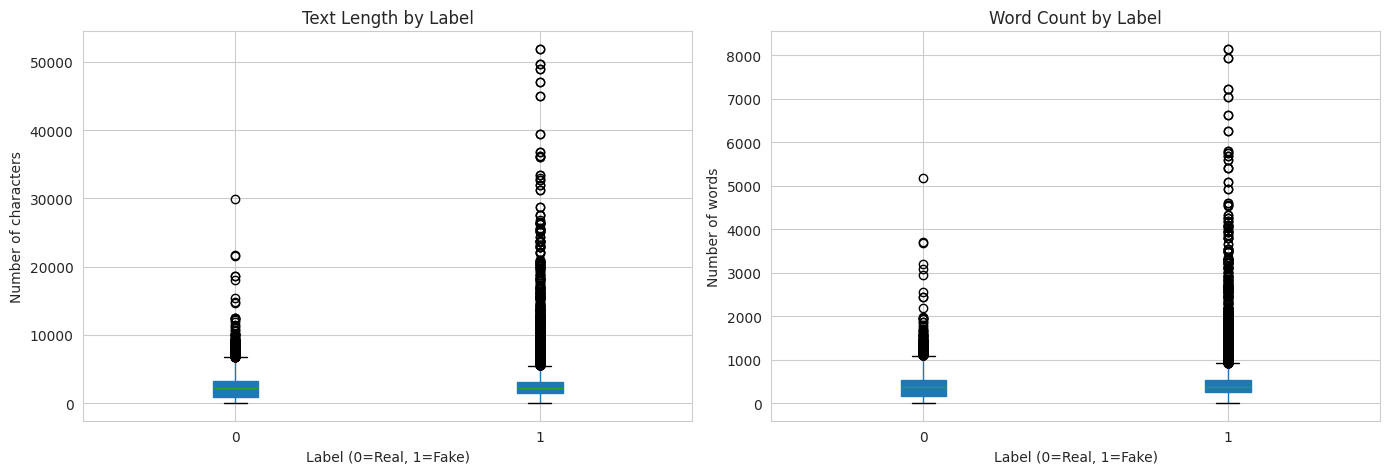

In [ ]:
# Boxplot להשוואה ויזואלית
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column="text_length", by="label", ax=axes[0],
           patch_artist=True)
axes[0].set_title("Text Length by Label")
axes[0].set_xlabel("Label (0=Real, 1=Fake)")
axes[0].set_ylabel("Number of characters")

df.boxplot(column="word_count", by="label", ax=axes[1],
           patch_artist=True)
axes[1].set_title("Word Count by Label")
axes[1].set_xlabel("Label (0=Real, 1=Fake)")
axes[1].set_ylabel("Number of words")

plt.suptitle("")
plt.tight_layout()
plt.show()

## (5) עיבוד מקדים בסיסי של הטקסט (Preprocessing)

לפני בניית מודל למידת מכונה, חייבים לנקות את הטקסט. נבצע את השלבים הבאים:

1. **המרה לאותיות קטנות** (lowercase) — מאחד ווריאציות כמו "Trump" ו-"trump"
2. **הסרת קישורים** (URLs) — מידע שאינו רלוונטי לתוכן
3. **הסרת סימנים ותווים שאינם אותיות** — פיסוק, מספרים, סמלים מיוחדים
4. **צמצום רווחים כפולים** — ניקוי הטקסט
5. **Tokenization בסיסי** (פיצול למילים) — שלב ראשון לייצוג וקטורי

In [ ]:
def clean_text(text):
    """
    פונקציית ניקוי טקסט בסיסית:
    - המרה לאותיות קטנות
    - הסרת URLs
    - שמירה על אותיות ורווחים בלבד
    - הסרת רווחים מיותרים
    """
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # הסרת קישורים
    text = re.sub(r"[^a-z\s]", " ", text)             # שמירת אותיות ורווחים בלבד
    text = re.sub(r"\s+", " ", text).strip()          # הסרת רווחים כפולים
    return text

# הפעלת הניקוי על כל הדאטה
df["clean_text"] = df["content"].apply(clean_text)

print("✅ ניקוי הטקסט הושלם!")
print(f"\nדוגמה — לפני הניקוי:")
print(df.loc[0, "content"][:200])
print(f"\nדוגמה — אחרי הניקוי:")
print(df.loc[0, "clean_text"][:200])

✅ ניקוי הטקסט הושלם!

דוגמה — לפני הניקוי:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out

דוגמה — אחרי הניקוי:
donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to 


In [ ]:
# הצגת השוואה בין טקסט מקורי למנוקה
df[["content", "clean_text"]].head()

,content,clean_text
0,"Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out...
1,"Drunk Bragging Trump Staffer Started Russian Collusion Investigation House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us,...",drunk bragging trump staffer started russian collusion investigation house intelligence committee chairman devin nunes is going to have a bad day he s been under the assumption like many of us tha...
2,"Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’ On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homel...",sheriff david clarke becomes an internet joke for threatening to poke people in the eye on friday it was revealed that former milwaukee sheriff david clarke who was being considered for homeland s...
3,"Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES) On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for the...",trump is so obsessed he even has obama s name coded into his website images on christmas day donald trump announced that he would be back to work the following day but he is golfing for the fourth...
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope delivere...,pope francis just called out donald trump during his christmas speech pope francis used his annual christmas day message to rebuke donald trump without even mentioning his name the pope delivered ...


### Tokenization בסיסי

**Tokenization** הוא תהליך פיצול הטקסט ליחידות קטנות יותר — **tokens** (בדרך כלל מילים).
זהו שלב בסיסי וחיוני לפני כל ייצוג וקטורי של טקסט (כגון Bag-of-Words, TF-IDF, Word2Vec).

In [ ]:
# Tokenization בסיסי — פיצול למילים
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

# סטטיסטיקות על מספר הטוקנים
df["token_count"] = df["tokens"].apply(len)
print("🔢 סטטיסטיקות מספר טוקנים:")
print(df["token_count"].describe().round(1))

print("\n📌 דוגמה לתוצאת tokenization:")
df[["clean_text", "tokens"]].head(3)

🔢 סטטיסטיקות מספר טוקנים:
count    44898.0
mean       423.2
std        357.1
min          0.0
25%        218.0
50%        380.0
75%        533.0
max       8295.0
Name: token_count, dtype: float64

📌 דוגמה לתוצאת tokenization:


,clean_text,tokens
0,donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out...,"[donald, trump, sends, out, embarrassing, new, year, s, eve, message, this, is, disturbing, donald, trump, just, couldn, t, wish, all, americans, a, happy, new, year, and, leave, it, at, that, ins..."
1,drunk bragging trump staffer started russian collusion investigation house intelligence committee chairman devin nunes is going to have a bad day he s been under the assumption like many of us tha...,"[drunk, bragging, trump, staffer, started, russian, collusion, investigation, house, intelligence, committee, chairman, devin, nunes, is, going, to, have, a, bad, day, he, s, been, under, the, ass..."
2,sheriff david clarke becomes an internet joke for threatening to poke people in the eye on friday it was revealed that former milwaukee sheriff david clarke who was being considered for homeland s...,"[sheriff, david, clarke, becomes, an, internet, joke, for, threatening, to, poke, people, in, the, eye, on, friday, it, was, revealed, that, former, milwaukee, sheriff, david, clarke, who, was, be..."


## (6) השוואה לפני ואחרי ניקוי (חשוב להגשה)

נציג השוואה ברורה בין הטקסט המקורי לטקסט המנוקה — זה חשוב להמחשת תהליך העיבוד המקדים.

In [ ]:
# הצגת דוגמאות לפני ואחרי ניקוי
for idx in [0, 1, 2]:
    label_name = "כוזב (Fake)" if df.loc[idx, "label"] == 1 else "אמיתי (Real)"
    print(f"\n{'='*80}")
    print(f"דוגמה #{idx+1} | מחלקה: {label_name}")
    print(f"{'='*80}")
    print("טקסט מקורי:")
    print(df.loc[idx, "content"][:400])
    print("\n" + "-"*80)
    print("טקסט מנוקה:")
    print(df.loc[idx, "clean_text"][:400])


דוגמה #1 | מחלקה: כוזב (Fake)
טקסט מקורי:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want t

--------------------------------------------------------------------------------
טקסט מנוקה:
donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all

דוגמה #2 | מחלקה: כוזב (Fake)
טקסט מקורי:
 Drunk Bragging Tr

## (7) שמירת הדאטה המעובד

נשמור את הדאטה המעובד לקובץ CSV כדי שנוכל להשתמש בו בשלב הבא — בניית המודל.

הקובץ יכיל:
- `content` — הטקסט המקורי
- `label` — התווית (0=אמיתי, 1=כוזב)
- `clean_text` — הטקסט המנוקה
- `text_length` — אורך הטקסט בתווים
- `word_count` — מספר מילים

In [ ]:
# שמירת הדאטה המעובד
output_cols = ["content", "clean_text", "label", "text_length", "word_count"]
df[output_cols].to_csv("fake_news_eda_preprocessed.csv", index=False)
print("✅ הדאטה המעובד נשמר בהצלחה: fake_news_eda_preprocessed.csv")
print(f"   מספר שורות: {len(df):,}")
print(f"   עמודות: {output_cols}")

✅ הדאטה המעובד נשמר בהצלחה: fake_news_eda_preprocessed.csv
   מספר שורות: 44,898
   עמודות: ['content', 'clean_text', 'label', 'text_length', 'word_count']


## (8) סיכום שלב 1

### מה בוצע בשלב זה:

| שלב | פעולה | כלי |
|-----|--------|-----|
| טעינת נתונים | קריאת Fake.csv ו-True.csv | `pandas.read_csv()` |
| הכנת תוויות | label=1 לכוזב, label=0 לאמיתי | pandas |
| איחוד טקסט | שילוב title + text → content | pandas |
| EDA | התפלגות מחלקות, אורך טקסט, מילים נפוצות | matplotlib, seaborn |
| Preprocessing | lowercase, הסרת URLs, ניקוי סימנים | `re` (regex) |
| Tokenization | פיצול למילים | Python split() |
| שמירה | ייצוא לCSV | `pandas.to_csv()` |

### ממצאים עיקריים:
- הדאטה כולל **~44,898 כתבות** — מאוזן יחסית בין שתי המחלקות
- אורך ממוצע של כתבה: **~4,500 תווים** / **~700 מילים**
- המילים הנפוצות ביותר הן מילות תפל (the, and, that) — יש צורך בהסרתן בשלב הבא
- ניתן לראות הבדלים בין כתבות כוזבות לאמיתיות בפיזור אורך הטקסט

### השלב הבא:
בניית מודל סיווג (Logistic Regression / SVM / Naive Bayes) על בסיס ייצוג **TF-IDF** של הטקסטים המנוקים.